# Vectorless RAG
> RAG without Vector DB, without Embeddings, without GPU

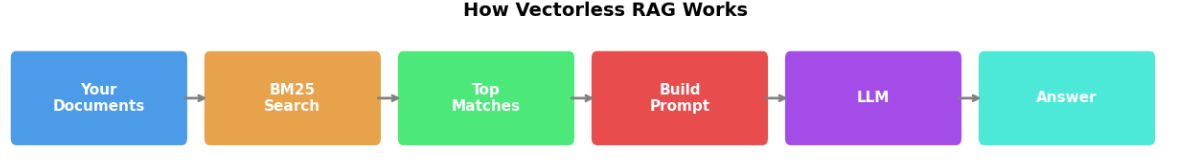

In [8]:
!pip install rank-bm25 python-dotenv groq -q
from rank_bm25 import BM25Okapi


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
DOCUMENTS = [
    {"title": "Python Basics",    "content": "Python is a high-level language known for simplicity. Uses indentation for code blocks."},
    {"title": "Machine Learning", "content": "ML models learn patterns from data. Algorithms: regression, decision trees, neural networks."},
    {"title": "RAG Systems",      "content": "RAG fetches relevant docs and passes them as context to an LLM. Reduces hallucinations."},
    {"title": "BM25 Algorithm",   "content": "BM25 ranks documents by term frequency and rarity. Used by Elasticsearch. No embeddings needed."},
    {"title": "Vector Databases", "content": "Vector DBs store embeddings for semantic search. Examples: Pinecone, ChromaDB, Qdrant."},
    {"title": "India Climate",    "content": "India has tropical to alpine zones. Monsoon June-September. Rajasthan is desert, Kerala is humid."},
    {"title": "Django",           "content": "Django is a Python web framework with ORM, auth, and admin panel built-in."},
]

corpus = [doc["content"].lower().split() for doc in DOCUMENTS] 
# sentence = "my name is nidhi", 
# Tonkens = ["my", "name", "is", "nidhi"]
bm25   = BM25Okapi(corpus)
print(f"{len(DOCUMENTS)} documents loaded, BM25 index ready!")

7 documents loaded, BM25 index ready!


In [10]:
def search(query, top_k=3):
    scores  = bm25.get_scores(query.lower().split())
    top_idx = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    return [{**DOCUMENTS[i], "score": round(scores[i], 3)} for i in top_idx if scores[i] > 0]

def build_prompt(query, docs):
    context = "\n".join(f"[{d['title']}]: {d['content']}" for d in docs)
    return f"Answer using ONLY the documents below.\n\n{context}\n\nQuestion: {query}\nAnswer:"

# Test search
for r in search("What is BM25?"):
    print(f"  [{r['score']}]  {r['title']}")

  [0.35]  India Climate
  [0.251]  Python Basics
  [0.251]  Django


In [11]:
# Demo Mode - no API key needed
def run_rag(query):
    docs = search(query)
    if not docs:
        print(f"Q: {query}\nA: Not in knowledge base.\n"); return
    print(f"Q: {query}\nA: {docs[0]['content']}\n")

run_rag("Tell me about machine learning")
run_rag("What is the climate in India?")
run_rag("What is quantum computing?")  # not in knowledge base

Q: Tell me about machine learning
A: Not in knowledge base.

Q: What is the climate in India?
A: India has tropical to alpine zones. Monsoon June-September. Rajasthan is desert, Kerala is humid.

Q: What is quantum computing?
A: India has tropical to alpine zones. Monsoon June-September. Rajasthan is desert, Kerala is humid.



In [14]:
# Real LLM via Groq - reads GROQ_API_KEY from .env file
import os
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

def run_rag_with_llm(query):
    docs   = search(query)
    prompt = build_prompt(query, docs)
    client = Groq(api_key=os.getenv("GROQ_API_KEY"))
    res    = client.chat.completions.create(
                 model="llama-3.1-8b-instant",
                 messages=[{"role": "user", "content": prompt}])
    print(f"Q: {query}\nA: {res.choices[0].message.content}\n")

run_rag_with_llm("Python Basics?")

Q: Python Basics?
A: Python is a high-level language known for simplicity. Uses indentation for code blocks.

